In [1]:
from helpers.data import load_bitcoin_prices, resample_ohlcv
from helpers.backtest import backtest_sma
import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

Scenario: 
- 2 months of data (max allowed by yfinance for intraday candles - just using now for simplicity).
- Basic SMA signal - buy when price moves above SMA, sell when moves below. 
- Which window size performs best for each candle size?


In [2]:
intervals = {'5m': None,
             '10m': '10min',
             '15m': '15min',
             '30m': '30min',
             '1h': '1h'}

btc_ohlcv = load_bitcoin_prices(interval='5m')
btc_ohlcv.columns = btc_ohlcv.columns.droplevel('Ticker')

In [3]:
windows = [5, 10, 20, 50, 100, 200]

backtests = {}
results = []

# Data is in 5m candles. Resample for larger candle sizes.
for interval_name, resample_rule in intervals.items():

    if resample_rule is None:
        interval_data = btc_ohlcv.copy()
    else:
        interval_data = resample_ohlcv(btc_ohlcv, resample_rule)

    # Backtest for each SMA window size
    for window in windows:
        result = backtest_sma(interval_data, window)

        backtests[(interval_name, window)] = result

        results.append({
            "interval": interval_name,
            "window": window,
            "total_return": result["cumulative_returns"].iloc[-1],
            "total_buys": result["cumulative_buys"].iloc[-1],
            "total_sells": result["cumulative_sells"].iloc[-1]
        })

results = pd.DataFrame(results)

In [4]:
results

,interval,window,total_return,total_buys,total_sells
0,5m,5,0.070940,2370,2370
1,5m,10,0.099565,1597,1597
2,5m,20,0.121318,1075,1075
3,5m,50,0.132465,682,682
4,5m,100,0.164484,472,471
5,5m,200,0.241897,295,294
6,10m,5,0.119069,1152,1152
7,10m,10,0.195889,791,791
8,10m,20,0.191962,530,530
9,10m,50,0.194816,332,331


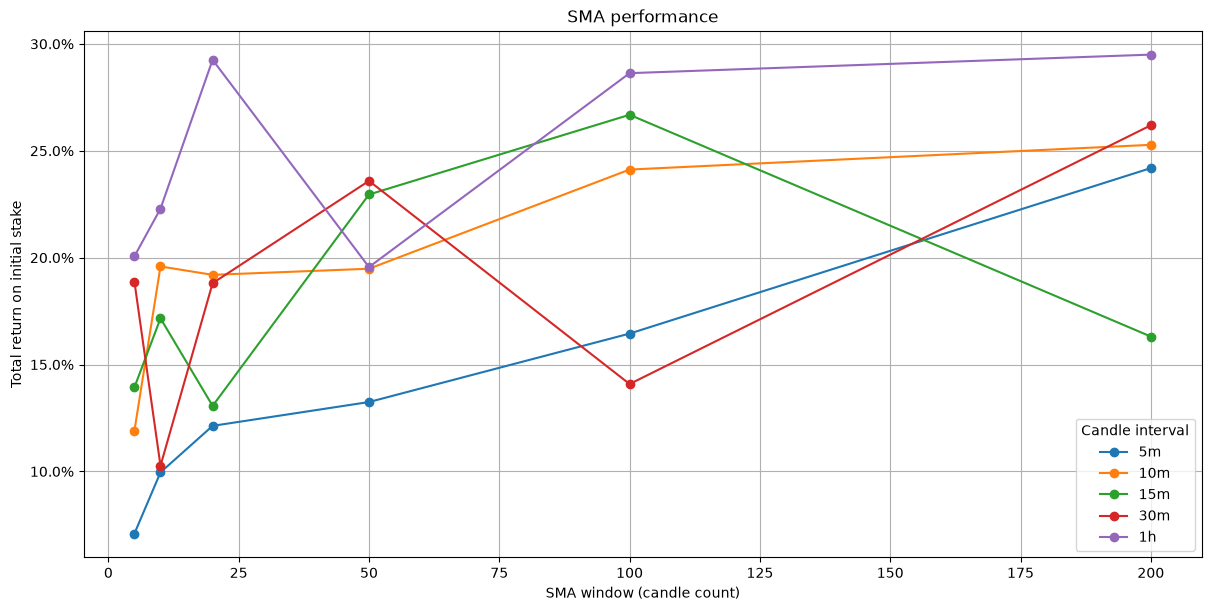

In [5]:
fig, ax = plt.subplots(figsize=(12, 6), layout='constrained')

for interval in intervals:
    results_on_interval = results[results["interval"] == interval]
    ax.plot(results_on_interval["window"], results_on_interval["total_return"], marker="o", label=interval)

ax.set_xlabel("SMA window (candle count)")
ax.set_ylabel("Total return on initial stake")
ax.set_title("SMA performance")
ax.legend(title="Candle interval")
ax.grid(which='both')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

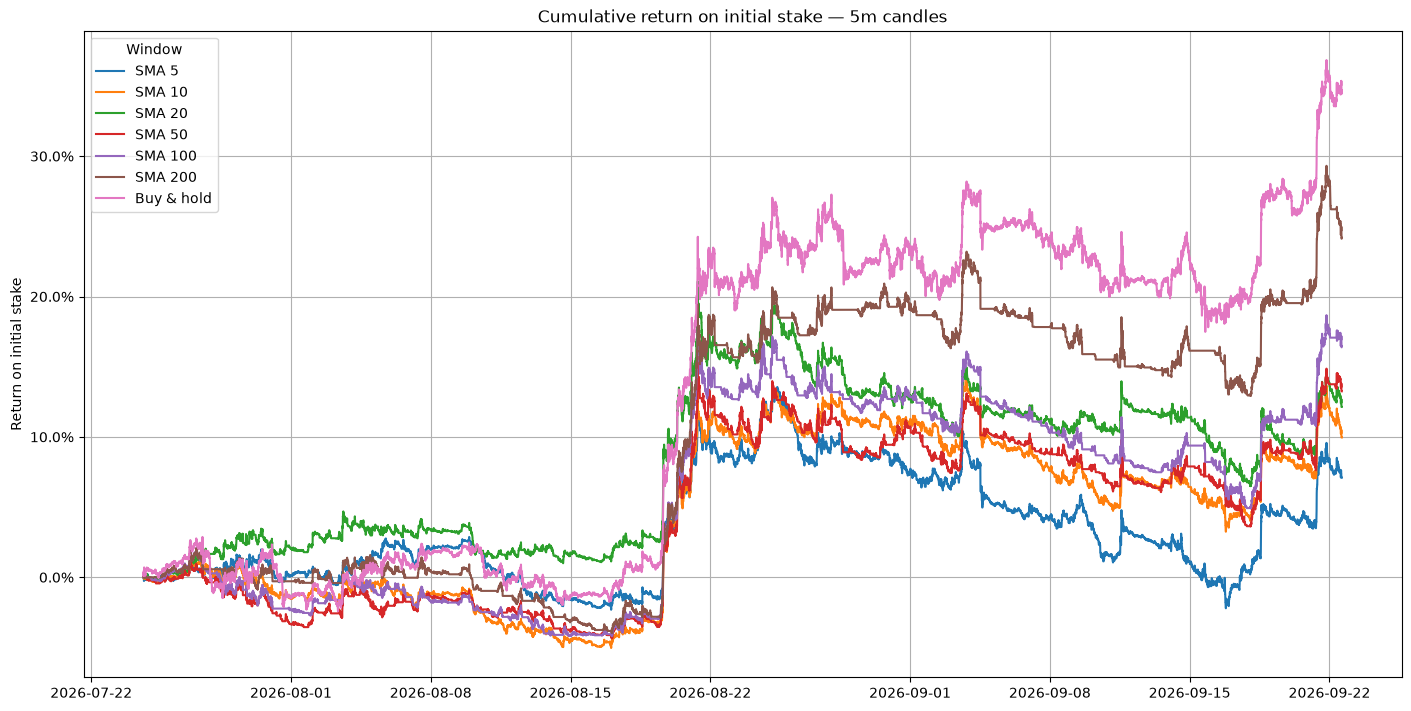

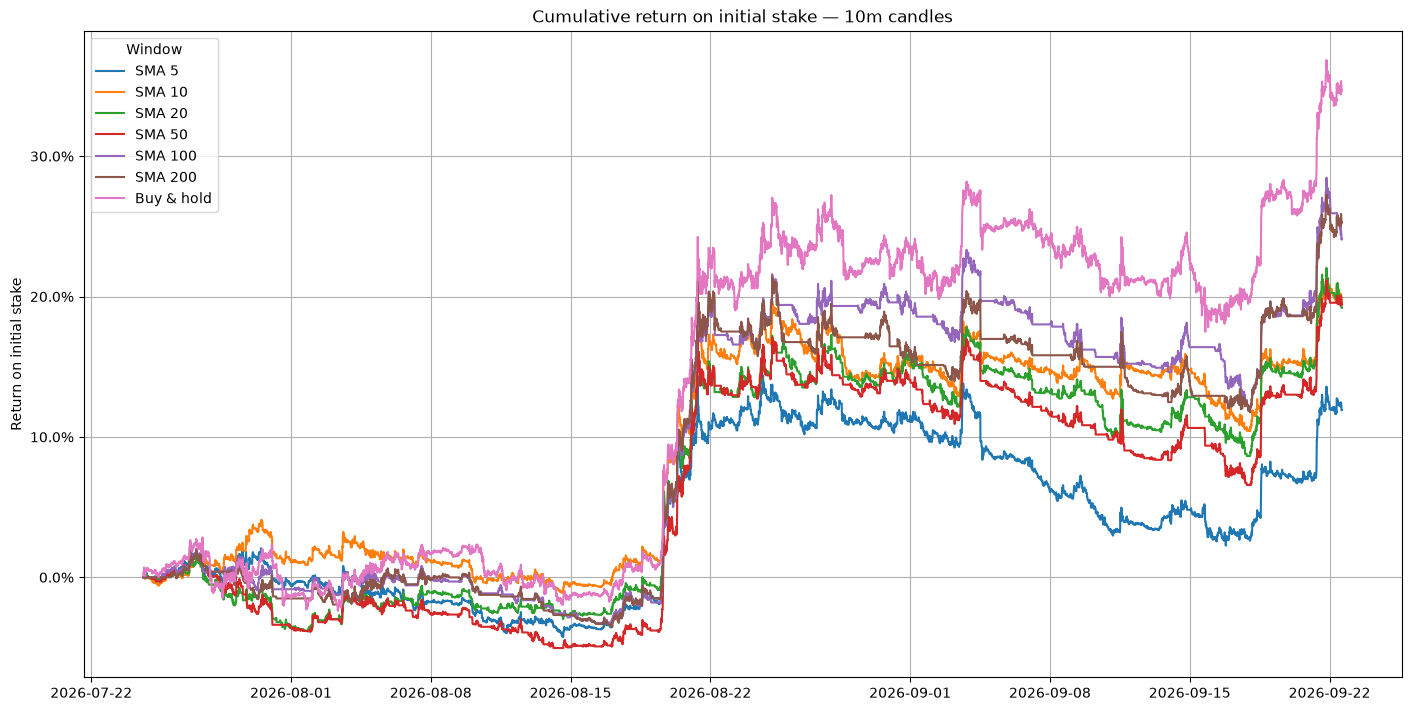

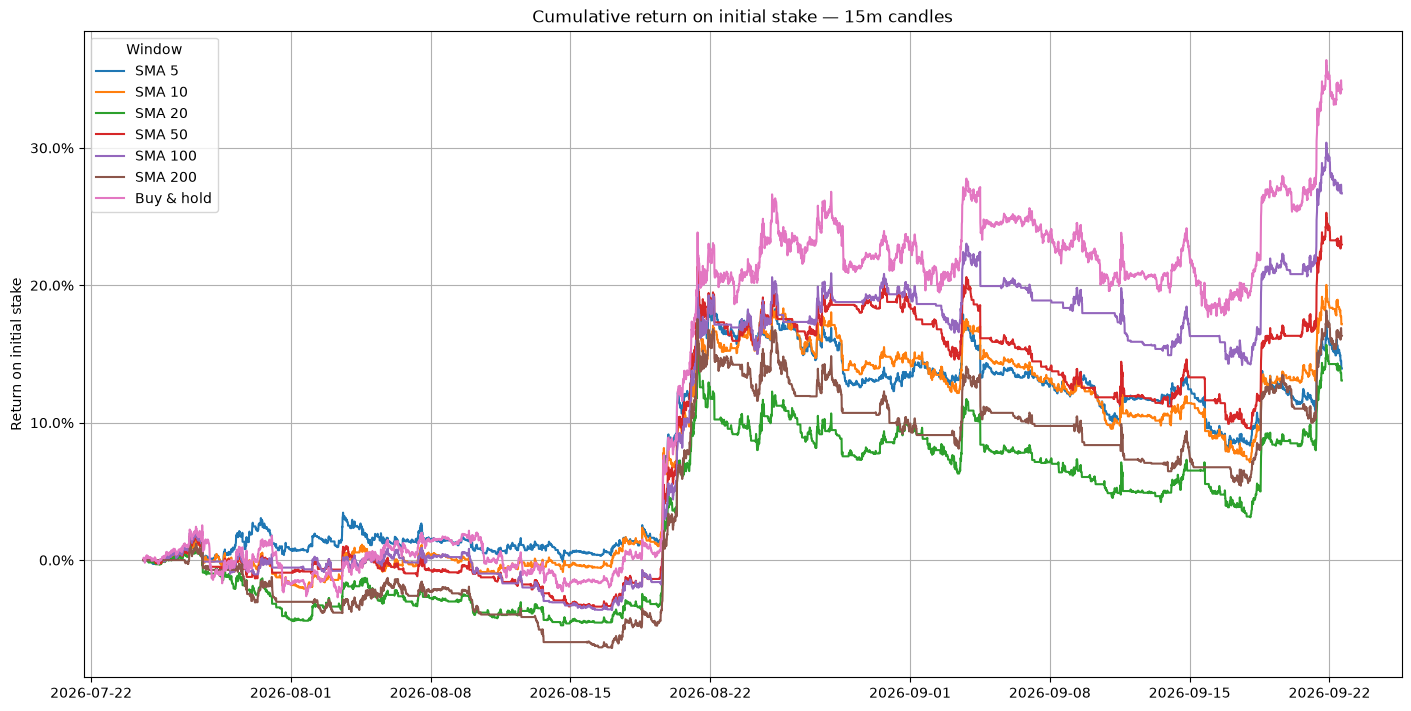

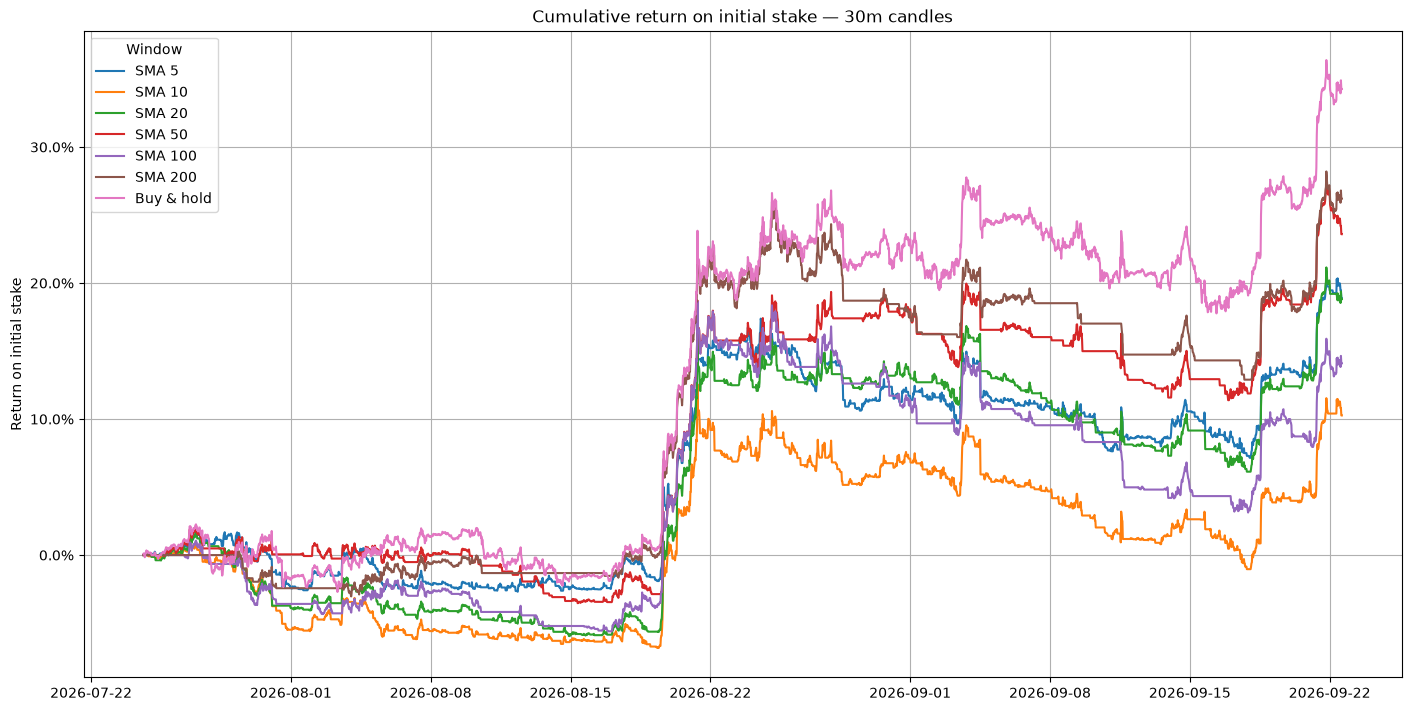

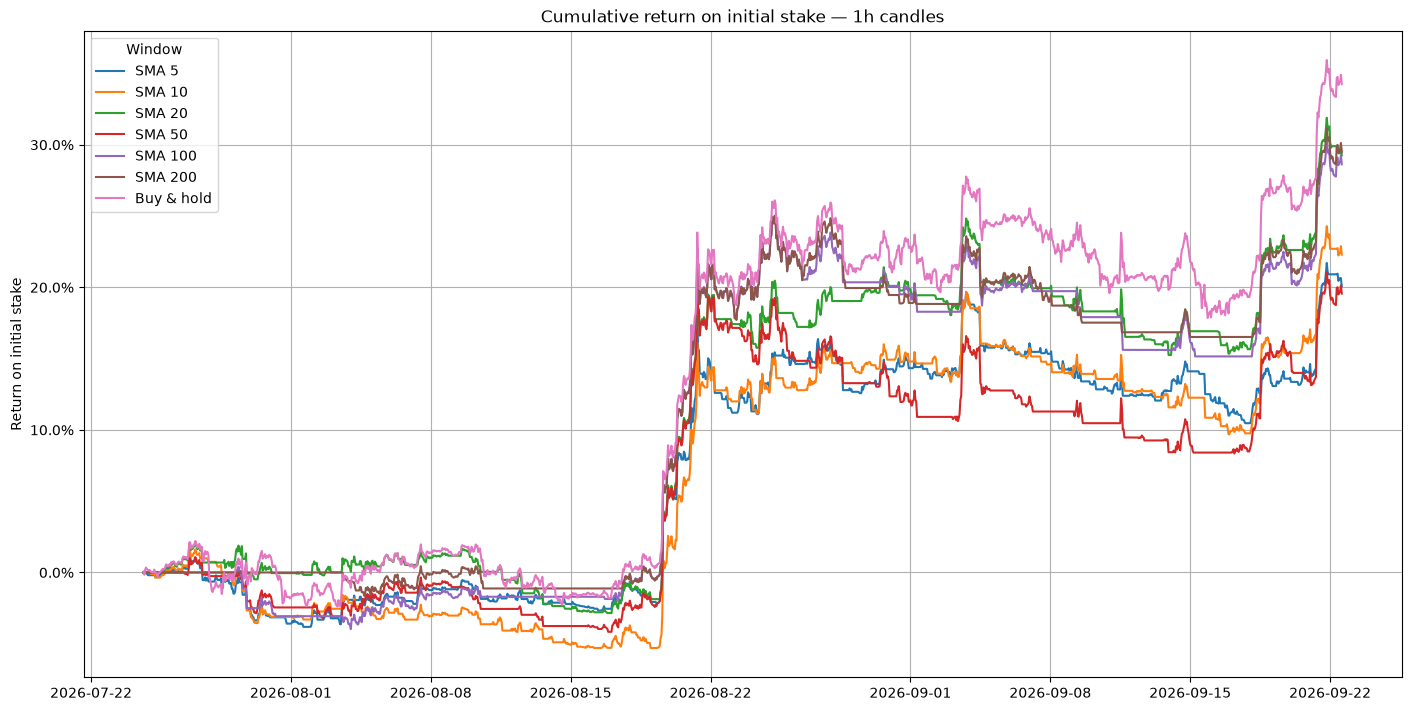

In [6]:
for interval in intervals.keys():

    fig, ax = plt.subplots(figsize=(14, 7), layout='constrained')

    for window in windows:
        result = backtests[(interval, window)]
        ax.plot(result["cumulative_returns"], label=f"SMA {window}")

    interval_data = btc_ohlcv.copy() if intervals[interval] is None else resample_ohlcv(btc_ohlcv, intervals[interval])

    buy_and_hold = (1+interval_data["Close"].pct_change()).cumprod() -1
    ax.plot(buy_and_hold, label="Buy & hold")

    ax.set_title(f"Cumulative return on initial stake — {interval} candles")
    ax.set_ylabel("Return on initial stake")
    ax.legend(title="Window")
    ax.grid(which='both')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))